<a href="https://colab.research.google.com/github/phuy29032007/Pham-Phung-Gia-Huy/blob/master/BTVN(04/05/2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Giá dự đoán: 80.00000000000004
Điểm thưởng: 80.00000000000004


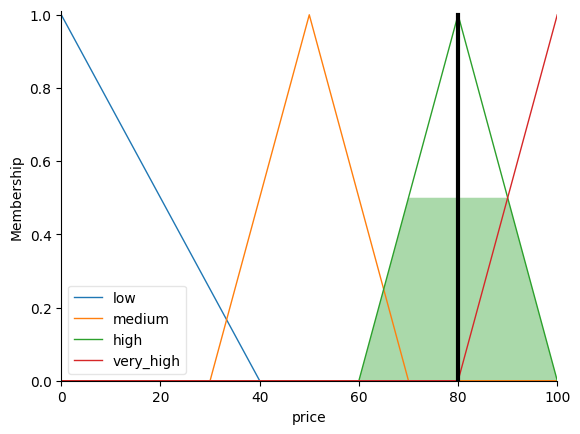

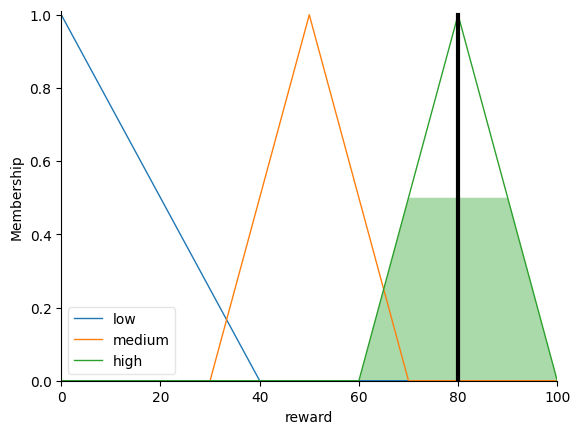

In [ ]:
#Bài 2.11
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')


traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')


demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')


weather = ctrl.Antecedent(np.arange(0, 11, 1), 'weather')
price = ctrl.Consequent(np.arange(0, 101, 1), 'price')
reward = ctrl.Consequent(np.arange(0, 101, 1), 'reward')
distance['short'] = fuzz.trimf(distance.universe, [0, 0, 5])
distance['medium'] = fuzz.trimf(distance.universe, [3, 10, 20])
distance['long'] = fuzz.trimf(distance.universe, [15, 30, 50])
traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 30])
traffic['medium'] = fuzz.trimf(traffic.universe, [20, 50, 80])
traffic['high'] = fuzz.trimf(traffic.universe, [60, 100, 100])
demand['low'] = fuzz.trimf(demand.universe, [0, 0, 30])
demand['medium'] = fuzz.trimf(demand.universe, [20, 50, 80])
demand['high'] = fuzz.trimf(demand.universe, [60, 100, 100])
weather['good'] = fuzz.trimf(weather.universe, [0, 0, 4])
weather['normal'] = fuzz.trimf(weather.universe, [3, 5, 7])
weather['bad'] = fuzz.trimf(weather.universe, [6, 10, 10])
price['low'] = fuzz.trimf(price.universe, [0, 0, 40])
price['medium'] = fuzz.trimf(price.universe, [30, 50, 70])
price['high'] = fuzz.trimf(price.universe, [60, 80, 100])
price['very_high'] = fuzz.trimf(price.universe, [80, 100, 100])

reward['low'] = fuzz.trimf(reward.universe, [0, 0, 40])
reward['medium'] = fuzz.trimf(reward.universe, [30, 50, 70])
reward['high'] = fuzz.trimf(reward.universe, [60, 80, 100])
rule1 = ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low'])
rule2 = ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium'])
rule3 = ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high'])
rule4 = ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium'])
rule5 = ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['very_high'])
rule6 = ctrl.Rule(distance['long'] & demand['high'], price['very_high'])
rule7 = ctrl.Rule(distance['medium'] & traffic['low'] & demand['low'], price['medium'])
rule8 = ctrl.Rule(distance['short'] & traffic['high'] & weather['bad'], price['high'])


rule9 = ctrl.Rule(demand['high'] & traffic['high'], reward['high'])
rule10 = ctrl.Rule(demand['medium'], reward['medium'])
rule11 = ctrl.Rule(demand['low'], reward['low'])
price_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
reward_ctrl = ctrl.ControlSystem([rule9, rule10, rule11])

price_sim = ctrl.ControlSystemSimulation(price_ctrl)
reward_sim = ctrl.ControlSystemSimulation(reward_ctrl)
price_sim.input['distance'] = 10
price_sim.input['traffic'] = 80
price_sim.input['demand'] = 90
price_sim.input['weather'] = 8

price_sim.compute()

reward_sim.input['demand'] = 90
reward_sim.input['traffic'] = 80

reward_sim.compute()

print("Giá dự đoán:", price_sim.output['price'])
print("Điểm thưởng:", reward_sim.output['reward'])
price.view(sim=price_sim)
reward.view(sim=reward_sim)


Mức giảm giá đề xuất (%): 30.350762591758933


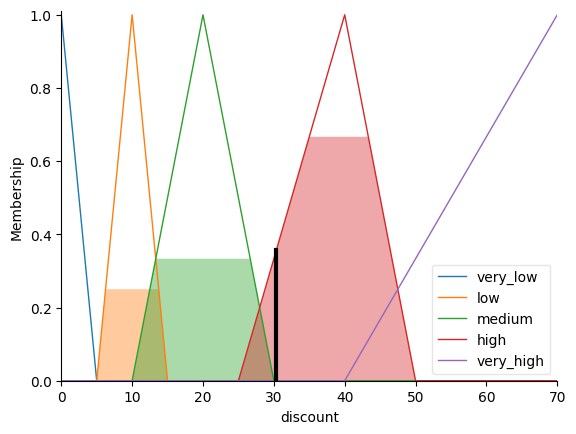

In [ ]:
#Bài 2.12
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'rating')
sales = ctrl.Antecedent(np.arange(0, 101, 1), 'sales')
profit = ctrl.Antecedent(np.arange(0, 101, 1), 'profit')
season = ctrl.Antecedent(np.arange(0, 11, 1), 'season')
competitor = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor')
discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

rating['low'] = fuzz.trimf(rating.universe, [0, 0, 4])
rating['medium'] = fuzz.trimf(rating.universe, [3.5, 4.2, 4.8])
rating['high'] = fuzz.trimf(rating.universe, [4.5, 5, 5])

sales['low'] = fuzz.trimf(sales.universe, [0, 0, 30])
sales['medium'] = fuzz.trimf(sales.universe, [20, 50, 80])
sales['high'] = fuzz.trimf(sales.universe, [60, 100, 100])

profit['low'] = fuzz.trimf(profit.universe, [0, 0, 30])
profit['medium'] = fuzz.trimf(profit.universe, [20, 50, 80])
profit['high'] = fuzz.trimf(profit.universe, [60, 100, 100])

season['none'] = fuzz.trimf(season.universe, [0, 0, 3])
season['medium'] = fuzz.trimf(season.universe, [2, 5, 8])
season['high'] = fuzz.trimf(season.universe, [7, 10, 10])

competitor['low'] = fuzz.trimf(competitor.universe, [0, 0, 30])
competitor['medium'] = fuzz.trimf(competitor.universe, [20, 50, 80])
competitor['high'] = fuzz.trimf(competitor.universe, [60, 100, 100])

discount['very_low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['low'] = fuzz.trimf(discount.universe, [5, 10, 15])
discount['medium'] = fuzz.trimf(discount.universe, [10, 20, 30])
discount['high'] = fuzz.trimf(discount.universe, [25, 40, 50])
discount['very_high'] = fuzz.trimf(discount.universe, [40, 70, 70])

rule1 = ctrl.Rule(profit['low'] & competitor['low'], discount['very_low'])
rule2 = ctrl.Rule(profit['medium'] & sales['medium'], discount['medium'])
rule3 = ctrl.Rule(profit['high'] & competitor['medium'], discount['medium'])
rule4 = ctrl.Rule(season['high'] & competitor['high'], discount['high'])
rule5 = ctrl.Rule(sales['low'] & rating['low'], discount['high'])
rule6 = ctrl.Rule(profit['low'] & sales['high'], discount['very_low'])
rule7 = ctrl.Rule(rating['high'] & profit['high'], discount['low'])
rule8 = ctrl.Rule(competitor['high'] & sales['low'], discount['very_high'])
rule9 = ctrl.Rule(season['high'] & sales['high'], discount['high'])
rule10 = ctrl.Rule(rating['medium'] & competitor['medium'], discount['medium'])
discount_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5,
    rule6, rule7, rule8, rule9, rule10
])

discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)
discount_sim.input['rating'] = 4.7
discount_sim.input['sales'] = 50
discount_sim.input['profit'] = 70
discount_sim.input['season'] = 9
discount_sim.input['competitor'] = 90
discount_sim.compute()
print("Mức giảm giá đề xuất (%):", discount_sim.output['discount'])

discount.view(sim=discount_sim)

Mức Giảm Giá:  15.0


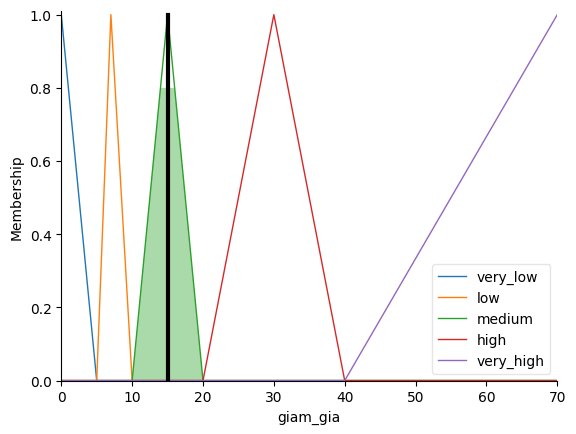

In [ ]:
#Bài 2.13
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Nhu_cau = ctrl.Antecedent(np.arange(0, 11, 1), 'Nhu_cau')
Doi_thu = ctrl.Antecedent(np.arange(0, 11, 1), 'Doi_thu')
Danh_tieng = ctrl.Antecedent(np.arange(0, 11, 1), 'Danh_tieng')
Loi_nhuan = ctrl.Antecedent(np.arange(0, 11, 1), 'Loi_nhuan')
Mua = ctrl.Antecedent(np.arange(0, 11, 1), 'Mua')

Nhu_cau['low'] = fuzz.trimf(Nhu_cau.universe, [0, 0, 5])
Nhu_cau['medium'] = fuzz.trimf(Nhu_cau.universe, [2, 5, 8])
Nhu_cau['high'] = fuzz.trimf(Nhu_cau.universe, [5, 10, 10])
Doi_thu['low'] = fuzz.trimf(Doi_thu.universe, [0, 0, 5])
Doi_thu['medium'] = fuzz.trimf(Doi_thu.universe, [2, 5, 8])
Doi_thu['high'] = fuzz.trimf(Doi_thu.universe, [5, 10, 10])
Danh_tieng['low'] = fuzz.trimf(Danh_tieng.universe, [0, 0, 5])
Danh_tieng['medium'] = fuzz.trimf(Danh_tieng.universe, [2, 5, 8])
Danh_tieng['high'] = fuzz.trimf(Danh_tieng.universe, [5, 10, 10])
Loi_nhuan['low'] = fuzz.trimf(Loi_nhuan.universe, [0, 0, 5])
Loi_nhuan['medium'] = fuzz.trimf(Loi_nhuan.universe, [2, 5, 8])
Loi_nhuan['high'] = fuzz.trimf(Loi_nhuan.universe, [5, 10, 10])
Mua['low'] = fuzz.trimf(Mua.universe, [0, 0, 5])
Mua['medium'] = fuzz.trimf(Mua.universe, [2, 5, 8])
Mua['high'] = fuzz.trimf(Mua.universe, [5, 10, 10])

giam_gia = ctrl.Consequent(np.arange(0, 71, 1), 'giam_gia')

giam_gia['very_low'] = fuzz.trimf(giam_gia.universe, [0, 0, 5])
giam_gia['low'] = fuzz.trimf(giam_gia.universe, [5, 7, 10])
giam_gia['medium'] = fuzz.trimf(giam_gia.universe, [10, 15, 20])
giam_gia['high'] = fuzz.trimf(giam_gia.universe, [20, 30, 40])
giam_gia['very_high'] = fuzz.trimf(giam_gia.universe, [40, 70, 70])

rules = [
ctrl.Rule(Nhu_cau['high'] & Doi_thu['low'] & Loi_nhuan['low'],giam_gia['very_low']),
ctrl.Rule(Nhu_cau['low'] & Doi_thu['high'] & Loi_nhuan['high'],giam_gia['high']),
ctrl.Rule(Danh_tieng['high'] & Loi_nhuan['medium'] & Mua['high'],giam_gia['medium']),
ctrl.Rule(Doi_thu['high'] & Mua['high'] & Loi_nhuan['high'],giam_gia['very_high']),
ctrl.Rule(Danh_tieng['low'] & Nhu_cau['medium'] & Loi_nhuan['low'], giam_gia['medium']),
ctrl.Rule(Nhu_cau['high'] & Mua['low'] & Doi_thu['low'],giam_gia['very_low']),
ctrl.Rule(Loi_nhuan['high'] & Doi_thu['medium'] & Mua['medium'],giam_gia['medium']),
]
system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)
sim.input['Nhu_cau'] = 9
sim.input['Doi_thu'] = 5
sim.input['Danh_tieng'] = 4.2
sim.input['Loi_nhuan'] = 9
sim.input['Mua'] = 5

sim.compute()

print("Mức Giảm Giá: ",sim.output['giam_gia'])
giam_gia.view(sim)

Orders to Combine:  8.514285714285712
Delivery Priority:  5.000000000000001


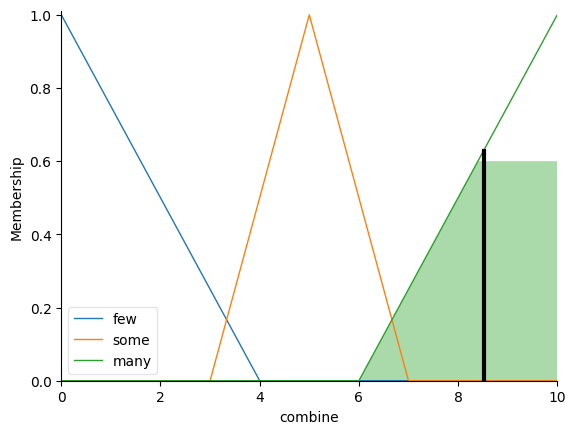

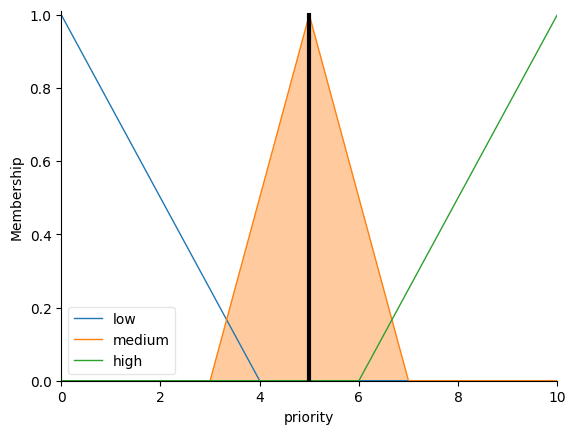

In [ ]:
#Bài 2.14
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

density = ctrl.Antecedent(np.arange(0, 11, 1), 'density')
urgency = ctrl.Antecedent(np.arange(0, 11, 1), 'urgency')
load = ctrl.Antecedent(np.arange(0, 11, 1), 'load')
traffic = ctrl.Antecedent(np.arange(0, 11, 1), 'traffic')
profit = ctrl.Antecedent(np.arange(0, 11, 1), 'profit')
combine = ctrl.Consequent(np.arange(0, 11, 1), 'combine')
priority = ctrl.Consequent(np.arange(0, 11, 1), 'priority')

def auto_membership(var):
    var['low'] = fuzz.trimf(var.universe, [0, 0, 5])
    var['medium'] = fuzz.trimf(var.universe, [2, 5, 8])
    var['high'] = fuzz.trimf(var.universe, [5, 10, 10])

for v in [density, urgency, load, traffic, profit]:
    auto_membership(v)

combine['few'] = fuzz.trimf(combine.universe, [0, 0, 4])
combine['some'] = fuzz.trimf(combine.universe, [3, 5, 7])
combine['many'] = fuzz.trimf(combine.universe, [6, 10, 10])
priority['low'] = fuzz.trimf(priority.universe, [0, 0, 4])
priority['medium'] = fuzz.trimf(priority.universe, [3, 5, 7])
priority['high'] = fuzz.trimf(priority.universe, [6, 10, 10])

rules = []
rules.append(ctrl.Rule(density['high'] & load['low'] & traffic['low'], combine['many']))
rules.append(ctrl.Rule(density['medium'] & traffic['high'] & urgency['medium'], combine['some']))
rules.append(ctrl.Rule(load['high'] & density['high'] & profit['medium'], combine['some']))
rules.append(ctrl.Rule(density['low'] & urgency['high'] & traffic['medium'], combine['some']))
rules.append(ctrl.Rule(profit['high'] & urgency['high'] & traffic['high'], combine['some']))

rules.append(ctrl.Rule(urgency['high'] & profit['high'], priority['high']))
rules.append(ctrl.Rule(urgency['medium'] & traffic['medium'], priority['medium']))
rules.append(ctrl.Rule(urgency['low'] & density['high'] & profit['low'], priority['low']))
rules.append(ctrl.Rule(density['high'] & load['low'] & traffic['medium'], combine['many']))

system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)
sim.input['density'] = 9
sim.input['urgency'] = 5
sim.input['load'] = 2
sim.input['traffic'] = 5
sim.input['profit'] = 5

sim.compute()

print("Orders to Combine: ", sim.output['combine'])
print("Delivery Priority: ", sim.output['priority'])
combine.view(sim=sim)
priority.view(sim=sim)
